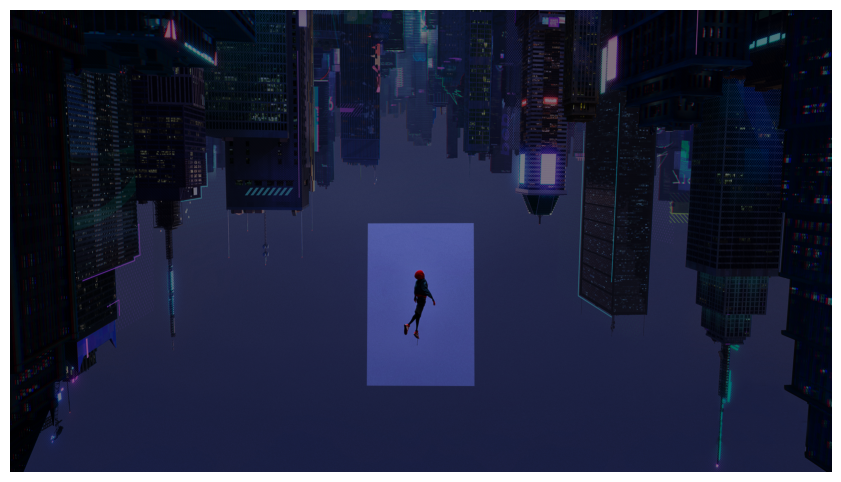

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_source = cv2.imread("wallppp.png")
img_target = cv2.imread("wallp.png")

gray1 = cv2.cvtColor(img_source, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img_target, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good = []

for m, n in matches:
    if m.distance < 0.8 * n.distance:
        good.append(m)

src_pts = np.float32(
    [kp1[m.queryIdx].pt for m in good]
).reshape(-1,1,2)

dst_pts = np.float32(
    [kp2[m.trainIdx].pt for m in good]
).reshape(-1,1,2)

H, mask = cv2.findHomography(
    src_pts,
    dst_pts,
    cv2.RANSAC,
    5.0
)

height, width = img_target.shape[:2]

registered = cv2.warpPerspective(
    img_source,
    H,
    (width, height)
)

result = cv2.addWeighted(
    img_target,
    0.5,
    registered,
    0.5,
    0
)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()